<a href="https://colab.research.google.com/github/Maithili-Badhan/Cognitive-Load-Estimator/blob/main/Cognitive_Load_Estimator_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d ziya07/emotional-monitoring-dataset

Dataset URL: https://www.kaggle.com/datasets/ziya07/emotional-monitoring-dataset
License(s): CC0-1.0


In [3]:
import zipfile

zip_data = zipfile.ZipFile('/content/emotional-monitoring-dataset.zip')
zip_data.extractall()
zip_data.close()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df1 = pd.read_csv("/content/emotional_monitoring_dataset_with_target.csv")

In [5]:
df1

,HeartRate,SkinConductance,EEG,Temperature,PupilDiameter,SmileIntensity,FrownIntensity,CortisolLevel,ActivityLevel,AmbientNoiseLevel,LightingLevel,EmotionalState,CognitiveState,EngagementLevel
0,61,8.937204,11.794946,36.501723,3.330181,0.689238,0.189024,0.603035,136,59,394,engaged,distracted,3
1,60,12.635397,19.151412,36.618910,3.428995,0.561056,0.091367,0.566671,155,39,479,engaged,distracted,1
2,81,3.660028,6.226098,36.176898,2.819286,0.417951,0.227355,1.422475,55,30,832,partially engaged,focused,3
3,119,0.563070,4.542968,37.205293,2.192961,0.140186,0.502965,1.669045,39,40,602,disengaged,focused,3
4,118,0.477378,0.996209,37.248118,2.450139,0.064471,0.695604,1.854076,10,42,908,disengaged,focused,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,98,3.897648,7.681519,36.274526,2.624275,0.404309,0.204719,1.215872,65,50,913,partially engaged,distracted,2
996,109,0.439062,0.352790,37.173929,2.489483,0.070776,0.638161,1.826544,23,43,642,disengaged,distracted,2
997,108,1.077287,1.836462,37.073454,2.370298,0.011001,0.595518,1.781096,8,43,620,disengaged,distracted,2
998,76,14.260010,19.309704,36.708047,3.393744,0.653693,0.171151,0.783958,110,38,779,engaged,distracted,1


In [6]:
df1.head()

,HeartRate,SkinConductance,EEG,Temperature,PupilDiameter,SmileIntensity,FrownIntensity,CortisolLevel,ActivityLevel,AmbientNoiseLevel,LightingLevel,EmotionalState,CognitiveState,EngagementLevel
0,61,8.937204,11.794946,36.501723,3.330181,0.689238,0.189024,0.603035,136,59,394,engaged,distracted,3
1,60,12.635397,19.151412,36.618910,3.428995,0.561056,0.091367,0.566671,155,39,479,engaged,distracted,1
2,81,3.660028,6.226098,36.176898,2.819286,0.417951,0.227355,1.422475,55,30,832,partially engaged,focused,3
3,119,0.563070,4.542968,37.205293,2.192961,0.140186,0.502965,1.669045,39,40,602,disengaged,focused,3
4,118,0.477378,0.996209,37.248118,2.450139,0.064471,0.695604,1.854076,10,42,908,disengaged,focused,3


# Exploratory Data Analysis

In [7]:
df1.shape

(1000, 14)

In [8]:
df1.columns

Index(['HeartRate', 'SkinConductance', 'EEG', 'Temperature', 'PupilDiameter',
       'SmileIntensity', 'FrownIntensity', 'CortisolLevel', 'ActivityLevel',
       'AmbientNoiseLevel', 'LightingLevel', 'EmotionalState',
       'CognitiveState', 'EngagementLevel'],
      dtype='object')

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HeartRate          1000 non-null   int64  
 1   SkinConductance    1000 non-null   float64
 2   EEG                1000 non-null   float64
 3   Temperature        1000 non-null   float64
 4   PupilDiameter      1000 non-null   float64
 5   SmileIntensity     1000 non-null   float64
 6   FrownIntensity     1000 non-null   float64
 7   CortisolLevel      1000 non-null   float64
 8   ActivityLevel      1000 non-null   int64  
 9   AmbientNoiseLevel  1000 non-null   int64  
 10  LightingLevel      1000 non-null   int64  
 11  EmotionalState     1000 non-null   object 
 12  CognitiveState     1000 non-null   object 
 13  EngagementLevel    1000 non-null   int64  
dtypes: float64(7), int64(5), object(2)
memory usage: 109.5+ KB


In [10]:
df1.describe()

,HeartRate,SkinConductance,EEG,Temperature,PupilDiameter,SmileIntensity,FrownIntensity,CortisolLevel,ActivityLevel,AmbientNoiseLevel,LightingLevel,EngagementLevel
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,89.428000,4.886971,8.493616,36.745107,2.833396,0.422318,0.348089,1.242361,83.349000,44.585000,655.651000,2.482000
std,17.339651,4.187668,5.616052,0.435840,0.535909,0.282820,0.236208,0.430722,54.734642,8.672369,197.732236,0.666423
min,60.000000,0.008741,0.019809,36.000958,2.000573,0.000875,0.000050,0.500255,0.000000,30.000000,302.000000,1.000000
25%,75.000000,1.602463,3.993575,36.370811,2.398951,0.155963,0.155691,0.860270,39.000000,37.000000,487.750000,2.000000
50%,89.000000,3.413038,7.400188,36.743273,2.747615,0.397790,0.290736,1.252747,76.000000,44.000000,654.500000,3.000000
75%,105.000000,7.719411,13.004892,37.115120,3.228348,0.650723,0.573842,1.612069,124.000000,52.000000,822.250000,3.000000
max,119.000000,14.998714,19.987929,37.498955,3.996728,0.998751,0.799369,1.999461,199.000000,59.000000,999.000000,3.000000


<Axes: >

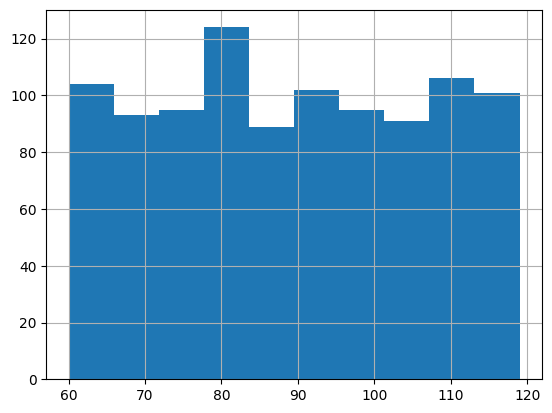

In [11]:
df1.HeartRate.hist()

<Axes: >

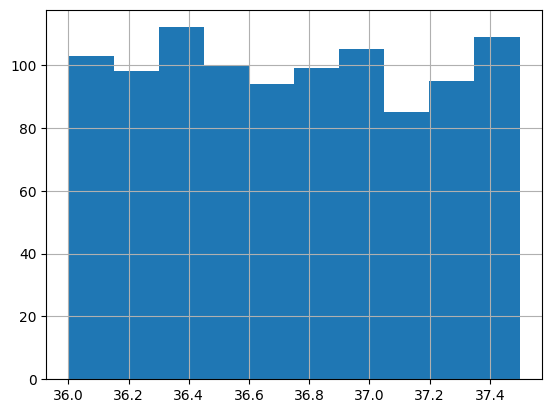

In [12]:
df1.Temperature.hist()

In [13]:
df1.isnull().sum()

,0
HeartRate,0
SkinConductance,0
EEG,0
Temperature,0
PupilDiameter,0
SmileIntensity,0
FrownIntensity,0
CortisolLevel,0
ActivityLevel,0
AmbientNoiseLevel,0


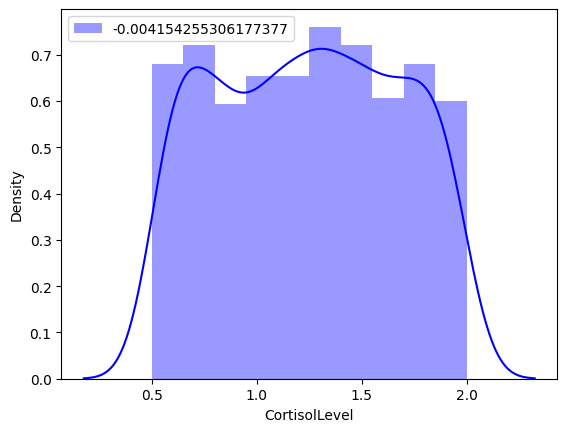

In [14]:
sns.distplot(df1['CortisolLevel'], label=df1['CortisolLevel'].skew(), color = 'b')
plt.legend()
plt.show()

In [15]:
def attribute_info(df_feature):
  print(f'Value Counts: \n{df_feature.value_counts()} \n')

In [16]:
for col in df1:
  print(f'\033[1m ---------------------------------------------{col}----------------------------------')
  attribute_info(df1[col])
  print('\n\n')

 ---------------------------------------------HeartRate----------------------------------
Value Counts: 
HeartRate
107    24
79     24
99     23
69     23
64     22
117    22
83     22
80     21
82     21
92     21
95     20
81     20
97     19
110    19
111    19
61     19
60     18
70     18
66     18
109    18
114    18
108    18
76     18
103    17
77     17
63     17
90     17
65     17
74     17
119    17
112    17
86     17
78     16
88     16
94     16
84     16
93     16
116    15
98     15
96     15
72     15
85     15
113    15
118    15
102    15
75     14
68     14
105    14
73     14
100    14
115    14
89     13
104    12
87     12
91     12
71     12
62     11
106     9
101     9
67      8
Name: count, dtype: int64 




 ---------------------------------------------SkinConductance----------------------------------
Value Counts: 
SkinConductance
4.676070     1
8.937204     1
12.635397    1
3.660028     1
0.563070     1
            ..
8.822559     1
13.156218    1
1.71151

#### Here the class 1 data is severly less compared to other classes. Thus ADASYN is applied to augment the data.

In [17]:
import pandas as pd
from imblearn.over_sampling import ADASYN

# 1️⃣ Load the dataset
file_path = "/content/emotional_monitoring_dataset_with_target.csv"  # Update if needed
df = pd.read_csv(file_path)

# 2️⃣ Encode categorical columns ('EmotionalState', 'CognitiveState') before applying ADASYN
df_encoded = df.copy()
df_encoded['EmotionalState'] = df_encoded['EmotionalState'].astype('category').cat.codes
df_encoded['CognitiveState'] = df_encoded['CognitiveState'].astype('category').cat.codes

# 3️⃣ Split Features (X) and Target (y)
X = df_encoded.drop(columns=['EngagementLevel'])  # Features
y = df_encoded['EngagementLevel']  # Target variable

# 4️⃣ Apply ADASYN only on class 1
adasyn = ADASYN(sampling_strategy={1: 579}, random_state=42)  # Match majority class (579)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

# 5️⃣ Convert back to DataFrame
df_augmented = pd.DataFrame(X_resampled, columns=X.columns)
df_augmented['EngagementLevel'] = y_resampled

# 6️⃣ Decode categorical variables back to original form
df_augmented['EmotionalState'] = df_augmented['EmotionalState'].round().astype(int)
df_augmented['CognitiveState'] = df_augmented['CognitiveState'].round().astype(int)

# 7️⃣ Save the new dataset
augmented_file_path = "/content/augmented_emotional-monitoring-dataset.csv"
df_augmented.to_csv(augmented_file_path, index=False)

print(f"Augmented dataset saved as {augmented_file_path}")

Augmented dataset saved as /content/augmented_emotional-monitoring-dataset.csv


In [18]:
df = pd.read_csv("/content/augmented_emotional-monitoring-dataset.csv")

In [19]:
df

,HeartRate,SkinConductance,EEG,Temperature,PupilDiameter,SmileIntensity,FrownIntensity,CortisolLevel,ActivityLevel,AmbientNoiseLevel,LightingLevel,EmotionalState,CognitiveState,EngagementLevel
0,61,8.937204,11.794946,36.501723,3.330181,0.689238,0.189024,0.603035,136,59,394,1,0,3
1,60,12.635397,19.151412,36.618910,3.428995,0.561056,0.091367,0.566671,155,39,479,1,0,1
2,81,3.660028,6.226098,36.176898,2.819286,0.417951,0.227355,1.422475,55,30,832,2,1,3
3,119,0.563070,4.542968,37.205293,2.192961,0.140186,0.502965,1.669045,39,40,602,0,1,3
4,118,0.477378,0.996209,37.248118,2.450139,0.064471,0.695604,1.854076,10,42,908,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1461,75,14.049274,19.357986,36.700435,3.428416,0.719163,0.154847,0.843024,110,37,784,1,0,1
1462,73,13.498264,18.946051,36.692066,3.453902,0.658814,0.158742,0.763780,115,40,787,1,0,1
1463,75,14.098549,19.346696,36.702215,3.420309,0.703854,0.158659,0.829213,110,37,783,1,0,1
1464,74,13.868906,19.399310,36.693920,3.458091,0.775199,0.140892,0.893578,111,36,789,1,0,1


In [20]:
def attribute_info(df_feature):
  print(f'Value Counts: \n{df_feature.value_counts()} \n')

In [21]:
for col in df:
  print(f'\033[1m ---------------------------------------------{col}----------------------------------')
  attribute_info(df[col])
  print('\n\n')

 ---------------------------------------------HeartRate----------------------------------
Value Counts: 
HeartRate
70     68
69     65
74     63
75     50
72     48
71     46
66     45
64     45
76     41
65     41
68     39
73     39
77     37
60     31
61     26
79     25
63     24
107    24
67     24
99     23
62     23
117    22
83     22
92     21
80     21
82     21
81     20
95     20
111    19
97     19
110    19
108    18
109    18
78     18
114    18
86     17
112    17
119    17
103    17
90     17
84     16
94     16
88     16
93     16
96     15
116    15
98     15
85     15
113    15
118    15
102    15
105    14
115    14
100    14
89     13
87     12
91     12
104    12
106     9
101     9
Name: count, dtype: int64 




 ---------------------------------------------SkinConductance----------------------------------
Value Counts: 
SkinConductance
13.519409    1
8.937204     1
12.635397    1
3.660028     1
0.563070     1
            ..
4.716625     1
14.536034    1
8.82255

# Outlier Detection

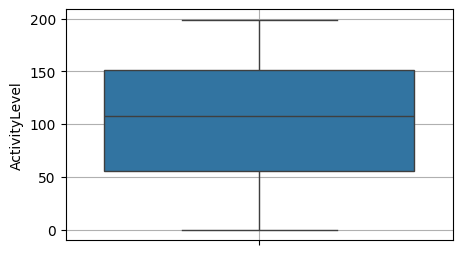

In [22]:
plt.figure(figsize = (5,3))
sns.boxplot(df['ActivityLevel'])
plt.grid()
plt.show()

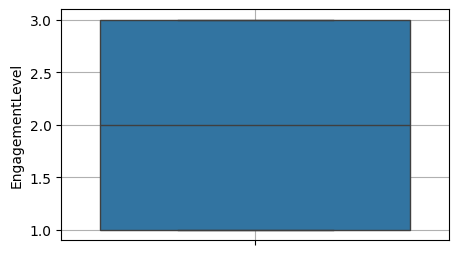

In [23]:
plt.figure(figsize = (5,3))
sns.boxplot(df['EngagementLevel'])
plt.grid()
plt.show()

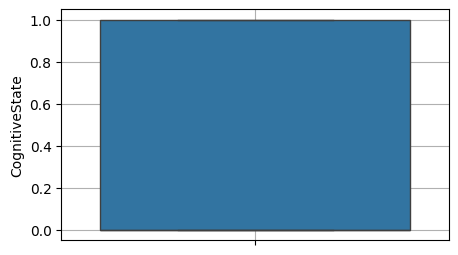

In [24]:
plt.figure(figsize = (5,3))
sns.boxplot(df['CognitiveState'])
plt.grid()
plt.show()

In [25]:
df

,HeartRate,SkinConductance,EEG,Temperature,PupilDiameter,SmileIntensity,FrownIntensity,CortisolLevel,ActivityLevel,AmbientNoiseLevel,LightingLevel,EmotionalState,CognitiveState,EngagementLevel
0,61,8.937204,11.794946,36.501723,3.330181,0.689238,0.189024,0.603035,136,59,394,1,0,3
1,60,12.635397,19.151412,36.618910,3.428995,0.561056,0.091367,0.566671,155,39,479,1,0,1
2,81,3.660028,6.226098,36.176898,2.819286,0.417951,0.227355,1.422475,55,30,832,2,1,3
3,119,0.563070,4.542968,37.205293,2.192961,0.140186,0.502965,1.669045,39,40,602,0,1,3
4,118,0.477378,0.996209,37.248118,2.450139,0.064471,0.695604,1.854076,10,42,908,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1461,75,14.049274,19.357986,36.700435,3.428416,0.719163,0.154847,0.843024,110,37,784,1,0,1
1462,73,13.498264,18.946051,36.692066,3.453902,0.658814,0.158742,0.763780,115,40,787,1,0,1
1463,75,14.098549,19.346696,36.702215,3.420309,0.703854,0.158659,0.829213,110,37,783,1,0,1
1464,74,13.868906,19.399310,36.693920,3.458091,0.775199,0.140892,0.893578,111,36,789,1,0,1


In [26]:
df.corr()

,HeartRate,SkinConductance,EEG,Temperature,PupilDiameter,SmileIntensity,FrownIntensity,CortisolLevel,ActivityLevel,AmbientNoiseLevel,LightingLevel,EmotionalState,CognitiveState,EngagementLevel
HeartRate,1.000000,-0.844620,-0.883454,0.378028,-0.872316,-0.891903,0.901676,0.905141,-0.864301,0.059032,0.010012,-0.381105,0.132297,0.432836
SkinConductance,-0.844620,1.000000,0.902673,-0.137946,0.845692,0.851233,-0.821300,-0.864063,0.833203,-0.106278,-0.023126,0.133134,-0.148167,-0.653478
EEG,-0.883454,0.902673,1.000000,-0.229446,0.884790,0.886625,-0.875802,-0.895800,0.874992,-0.085662,-0.018640,0.231061,-0.165376,-0.605007
Temperature,0.378028,-0.137946,-0.229446,1.000000,-0.268599,-0.310903,0.472512,0.341785,-0.261308,-0.046344,0.007643,-0.926749,0.029668,0.023738
PupilDiameter,-0.872316,0.845692,0.884790,-0.268599,1.000000,0.881325,-0.865320,-0.882980,0.845566,-0.039262,-0.030587,0.270514,-0.110712,-0.458824
SmileIntensity,-0.891903,0.851233,0.886625,-0.310903,0.881325,1.000000,-0.885548,-0.901844,0.866448,-0.046321,-0.000781,0.321010,-0.131392,-0.453650
FrownIntensity,0.901676,-0.821300,-0.875802,0.472512,-0.865320,-0.885548,1.000000,0.902444,-0.854822,0.069551,0.019420,-0.501336,0.127698,0.435378
CortisolLevel,0.905141,-0.864063,-0.895800,0.341785,-0.882980,-0.901844,0.902444,1.000000,-0.871658,0.071689,0.008126,-0.358525,0.134796,0.463373
ActivityLevel,-0.864301,0.833203,0.874992,-0.261308,0.845566,0.866448,-0.854822,-0.871658,1.000000,-0.051731,-0.024285,0.273849,-0.135312,-0.446435
AmbientNoiseLevel,0.059032,-0.106278,-0.085662,-0.046344,-0.039262,-0.046321,0.069551,0.071689,-0.051731,1.000000,0.018211,0.011072,0.052056,0.105834


<Axes: >

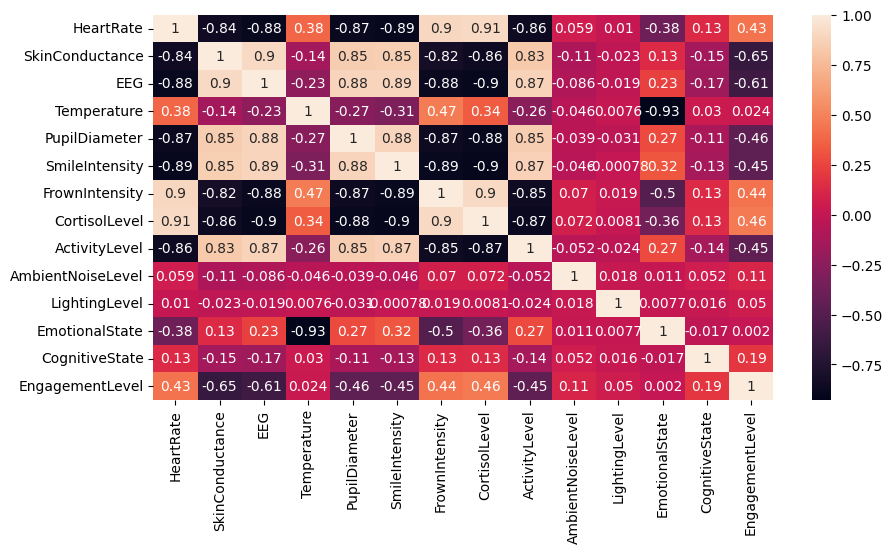

In [27]:
plt.figure(figsize = (10,5))
sns.heatmap(df.corr(), annot = True)

In [28]:
dcor = abs(df.corr()['EngagementLevel']).sort_values(ascending = False)
dcor

,EngagementLevel
EngagementLevel,1.000000
SkinConductance,0.653478
EEG,0.605007
CortisolLevel,0.463373
PupilDiameter,0.458824
SmileIntensity,0.453650
ActivityLevel,0.446435
FrownIntensity,0.435378
HeartRate,0.432836
CognitiveState,0.190737


# Model Building

## Logistic Regression

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [30]:
X = df.drop('EngagementLevel', axis = 1)
y = df['EngagementLevel']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
# Train a logistic regression model
lr_model = LogisticRegression(multi_class="auto", solver="lbfgs", max_iter=500)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=500, multi_class='auto')

Accuracy: 0.7619
              precision    recall  f1-score   support

           1       0.95      1.00      0.98       120
           2       0.54      0.44      0.48        68
           3       0.66      0.70      0.68       106

    accuracy                           0.76       294
   macro avg       0.72      0.71      0.71       294
weighted avg       0.75      0.76      0.75       294



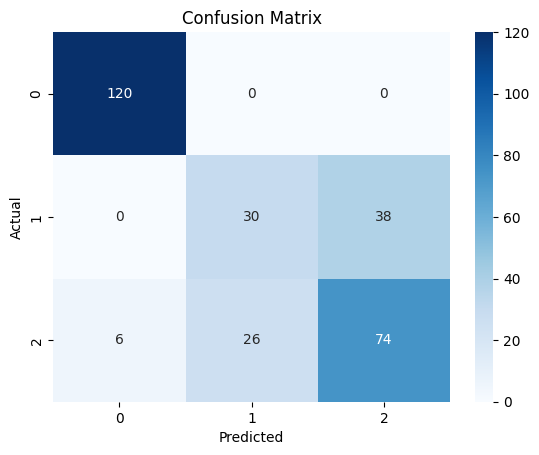

In [32]:
# Predict on test data
y_pred = lr_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification report
print(classification_report(y_test, y_pred, target_names=[str(cls) for cls in le.classes_]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
train_acc = accuracy_score(y_train, lr_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

Training Accuracy: 0.7713
Testing Accuracy: 0.7619


## Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(
    n_estimators=50,  # Reduce number of trees
    max_depth=3,  # Limit tree depth
    min_samples_split=10,  # Minimum samples required to split
    min_samples_leaf=4,  # Minimum samples in leaf node
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Cross-validation for better evaluation
cv_scores = cross_val_score(rf_model, X, y, cv=5)  # 5-fold cross-validation

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Random Forest Accuracy: 0.9728
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       120
           1       0.98      0.91      0.95        68
           2       0.94      0.99      0.96       106

    accuracy                           0.97       294
   macro avg       0.97      0.96      0.97       294
weighted avg       0.97      0.97      0.97       294

Cross-Validation Accuracy: 0.9966 ± 0.0022


## SVM

In [35]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced", probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.95578231292517
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       120
           1       0.92      1.00      0.96        68
           2       1.00      0.88      0.93       106

    accuracy                           0.96       294
   macro avg       0.95      0.96      0.95       294
weighted avg       0.96      0.96      0.96       294



# Model Comparison

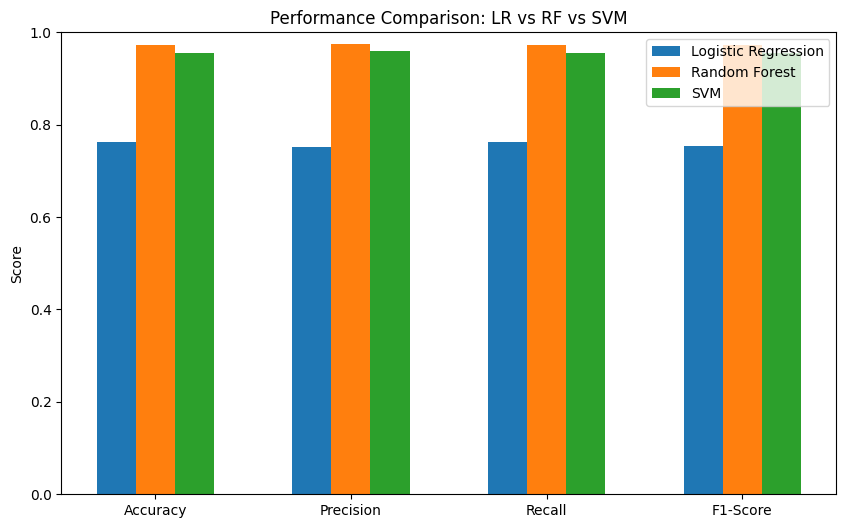

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store model results in a dictionary
model_results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted"),
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average="weighted"),
        "Recall": recall_score(y_test, y_pred_rf, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_rf, average="weighted"),
    },
    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm, average="weighted"),
        "Recall": recall_score(y_test, y_pred_svm, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_svm, average="weighted"),
    },
}

# Convert dictionary to NumPy array
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores = np.array([[model_results[model][metric] for metric in metrics] for model in model_results])

# Bar plot
bar_width = 0.2
x = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
for i, (model, score) in enumerate(model_results.items()):
    plt.bar(x + i * bar_width, list(score.values()), width=bar_width, label=model)

plt.xticks(x + bar_width, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison: LR vs RF vs SVM")
plt.legend()
plt.ylim(0, 1)
plt.show()

In [37]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=87a78e4187d038c96cbced9f46a71a6491dce39a23ed8dcba4980cfc3c38cbcd
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


# LIME Explainer


🔍 LIME Explanation for Logistic Regression:


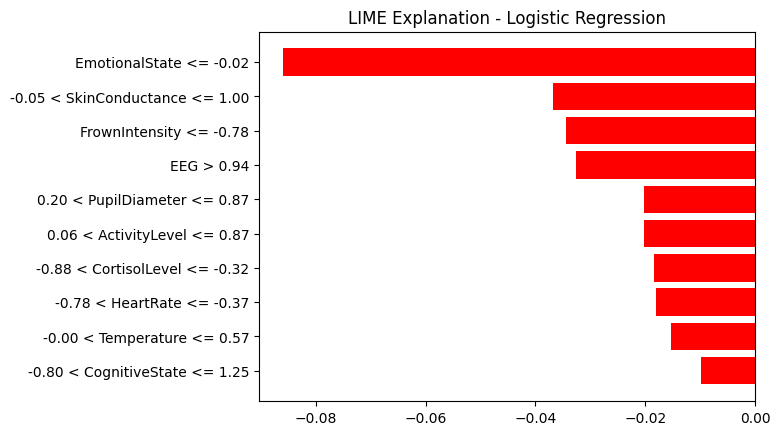


🔍 LIME Explanation for Random Forest:


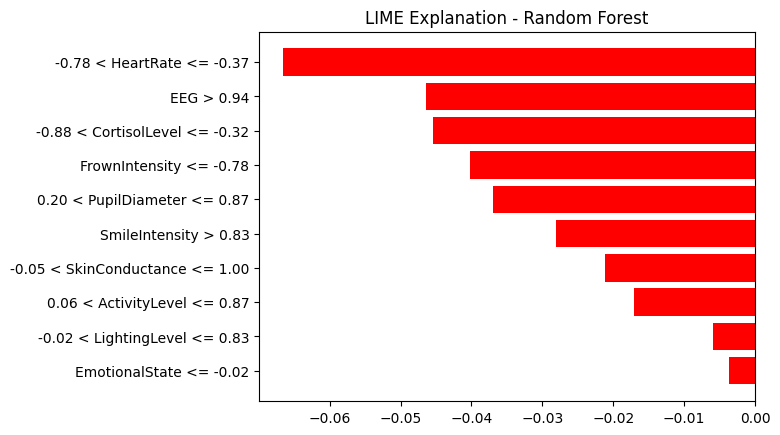


🔍 LIME Explanation for SVM (requires probability=True):


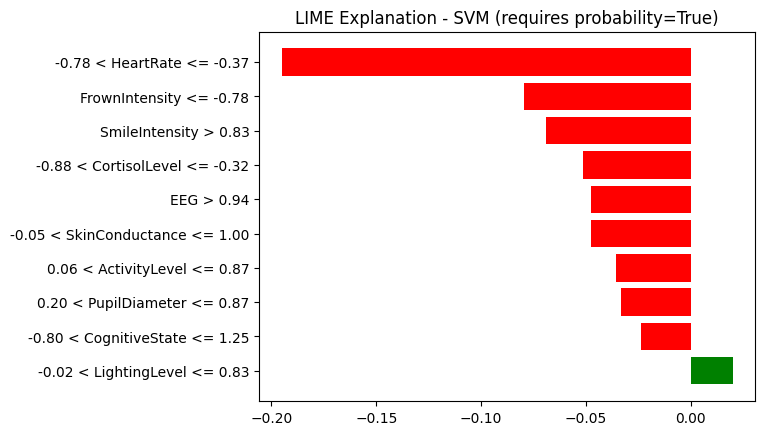

In [38]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=X.columns,
    class_names=le.classes_,
    discretize_continuous=True
)

# Select a test instance to explain
idx = np.random.randint(0, X_test.shape[0])  # Pick a random test sample
sample = X_test[idx].reshape(1, -1)

# Function to explain model predictions
def explain_model(model, model_name):
    exp = explainer.explain_instance(sample.flatten(), model.predict_proba)
    print(f"\n🔍 LIME Explanation for {model_name}:")
    exp.show_in_notebook()
    exp.as_pyplot_figure()
    plt.title(f"LIME Explanation - {model_name}")
    plt.show()

# Explain each model
explain_model(lr_model, "Logistic Regression")
explain_model(rf_model, "Random Forest")
explain_model(svm_model, "SVM (requires probability=True)")

# Conclusion

If Class 0 is Critical (e.g., detecting high cognitive load in critical situations):
➡ Use SVM (perfect recall for Class 0).

If Overall Accuracy & Stability Matter:
➡ Stick with Random Forest (better balance across classes).